In [ ]:
# 2024.08.05 PDA HW 19 Inna Maslyaeva

''' 1 Повторите первичный анализ датасета used_cars_data после всех преобразований,
сделанных на уроке. Определите, типы каких столбцов теперь можно изменить.
Сделайте это.

2 Повторите одномерный анализ прологорифмированных столбцов и столбцов,
в которых были заполнены пропущенные значения.

3 Выведите информацию о самых крайних выбросах всех столбцов. Проанализируйте,
есть ли среди них ошибки ввода. Ликвидируйте их любым способом,
учитывающим специфику данных. '''


' 1 Повторите первичный анализ датасета used_cars_data после всех преобразований,\nсделанных на уроке. Определите, типы каких столбцов теперь можно изменить.\nСделайте это.\n\n2 Повторите одномерный анализ прологорифмированных столбцов и столбцов,\nв которых были заполнены пропущенные значения.\n\n3 Выведите информацию о самых крайних выбросах всех столбцов. Проанализируйте,\nесть ли среди них ошибки ввода. Ликвидируйте их любым способом,\nучитывающим специфику данных. '

In [ ]:
''' 1 Повторите первичный анализ датасета used_cars_data после всех преобразований,
сделанных на уроке.
Определите, типы каких столбцов теперь можно изменить.
Сделайте это.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#link = 'https://drive.google.com/file/d/1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-/view'
link = 'https://drive.google.com/uc?id=1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-'
data = pd.read_csv(link)
data.head(3)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50


In [ ]:
data.tail(3)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.0 kmpl,2148 CC,170 bhp,5.0,NaN,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [ ]:
data.isnull().sum()

,0
S.No.,0
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Mileage,2
Engine,46


In [ ]:
data.nunique()

,0
S.No.,7253
Name,2041
Location,11
Year,23
Kilometers_Driven,3660
Fuel_Type,5
Transmission,2
Owner_Type,4
Mileage,450
Engine,150


In [ ]:
data.describe(include='all').T # возможно здесь проанализирован последний вариант данных - последние 2 столбца

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
S.No.,7253.0,NaN,NaN,NaN,3626.0,2093.905084,0.0,1813.0,3626.0,5439.0,7252.0
Name,7253,2041,Mahindra XUV500 W8 2WD,55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,7253,11,Mumbai,949,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,7253.0,NaN,NaN,NaN,2013.365366,3.254421,1996.0,2011.0,2014.0,2016.0,2019.0
Kilometers_Driven,7253.0,NaN,NaN,NaN,58699.063146,84427.720583,171.0,34000.0,53416.0,73000.0,6500000.0
Fuel_Type,7253,5,Diesel,3852,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,7253,2,Manual,5204,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner_Type,7253,4,First,5952,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mileage,7251,450,17.0 kmpl,207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Engine,7207,150,1197 CC,732,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
data[data.duplicated()]

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price


In [ ]:
''' Выводы:
В нашем наборе данных 7253 ()строки 0 - 7252 наблюдения и 14 столбцов:
S.No., Name,	Location,	Year,	Kilometers,_Driven,	Fuel_Type,	Transmission,
Owner_Type,	Mileage,	Engine,	Power,	Seats,	New_Price,	Price .

Столбцы Mileage(2), Engine(46), Power(46), Seats(53), New_Price(6247) и Price(1234) имеют отсутствующие значения:

Числовые переменные: имеют тип данных float64 или int64:
S.No.              7253 non-null   int64
Year               7253 non-null   int64
Kilometers_Driven  7253 non-null   int64
Seats              7200 non-null   float64
Price              6019 non-null   float64

Категориальные переменные: такие как Location, Fuel_Type, Transmission и Owner Type,
имеют тип данных объекта.
Name               7253 non-null   object
Location           7253 non-null   object
Fuel_Type          7253 non-null   object
Transmission       7253 non-null   object
Owner_Type         7253 non-null   object
Mileage            7251 non-null   object
Engine             7207 non-null   object
Power              7207 non-null   object
New_Price          1006 non-null   object

Отсутствующие значения в  столбцах:
Mileage                 2
Engine                 46
Power                  46
Seats                  53
New_Price            6247
Price                1234

Уникальные данные - значения в столбцах:
S.No.                7253
Name                 2041
Location               11
Year                   23
Kilometers_Driven    3660
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               450
Engine                150
Power                 386
Seats                   9
New_Price             625
Price                1373

Повторяющихся данных (дубликатов строк) в датасете нету.

'''

In [ ]:
data.head(3)


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50


In [ ]:
# Определите, типы каких столбцов теперь можно изменить.
'''
                                        Был тип данных:  Можно изменить:
 0   S.No.              7253 non-null   int64           - можно удалить
 1   Name               7253 non-null   object          - нужно развить на несколько составляющих: модель + марка (серия, номер?)
 2   Location           7253 non-null   object          -
 3   Year               7253 non-null   int64           - изменить тип данных на числовой int64
 4   Kilometers_Driven  7253 non-null   int64           -

 5   Fuel_Type          7253 non-null   object          -
 6   Transmission       7253 non-null   object          -
 7   Owner_Type         7253 non-null   object          - изменить тип данных на числовой int64 - 1,2,3,4, но, поскольку 4+б тип НЕ меняем
 8   Mileage            7251 non-null   object          - изменить тип данных на числовой float64 - оставить только число float, убрать единицы измерения
 9   Engine             7207 non-null   object          - изменить тип данных на числовой int64- оставить только число int, убрать единицы измерения

 10  Power              7207 non-null   object          - изменить тип данных на числовой float64 - оставить только число float, убрать единицы измерения
 11  Seats              7200 non-null   float64         - изменить тип данных на целое число int64
 12  New_Price          1006 non-null   object
 13  Price              6019 non-null   float64         - изменить формирование итоговой цены. Здесь это будет максимум между старой ценой и новой ценой
 '''

In [ ]:
# начальный массив - скачиваем еще раз -------------------------------------------------------------------
import pandas as pd
import numpy as np
from datetime import date
#import matplotlib.pyplot as plt
#import seaborn as sns

link = 'https://drive.google.com/uc?id=1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-'
data = pd.read_csv(link)
data.head(3)

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50


In [ ]:
# 1 удаляем самый первый столбец 'S.No.'
# Анализ ситуации
print( data['S.No.'].info() )
print( data['S.No.'].unique() )
#print( data.S.No.isnull().sum() )

del data['S.No.']
data.head(3)

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: S.No.
Non-Null Count  Dtype
--------------  -----
7253 non-null   int64
dtypes: int64(1)
memory usage: 56.8 KB
None
[   0    1    2 ... 7250 7251 7252]


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50


In [ ]:
# 2 1.разбиваем столбец Name на Brand	и Model и 2. удаляем Name
# Анализ ситуации
#print( data['Name'].info() )
#print( data['Name'].unique() )
#print( data.Name.isnull().sum() )
#data.head(3)

# Преобразование необработанных данных
data['Brand'] = data.Name.str.split().str.get(0)
data['Model'] = data.Name.str.split().str.get(1) + ' ' + data.Name.str.split().str.get(2)
#data.sample(3)

# 2.2 удаляем Name
del data['Name']
#data.sample(3)

# 2.3 правим бренды - марки авто
Brands = data.Brand.unique()
#Brands

data["Brand"] = data["Brand"].replace({"ISUZU":"Isuzu", "Mini":"Mini Cooper","Land":"Land Rover", "OpelCorsa":"Opel"})
Brands = data.Brand.unique()
#Brands

# for i in range(len(data)):
#     # if data["Brand"][i] == 'Opel':
#             # data["Model"][i] = 'Corsa ' + data["Model"]
#     print(i, data["Model"][i], end=' ')

##Model = data.Model.unique()
#Model[:10:]

# Анализ ситуации
print( data['Model'].info() )
#print( data['Model'].unique() )
print( data.Model.isnull().sum() )
data.head(3)

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Model
Non-Null Count  Dtype 
--------------  ----- 
7252 non-null   object
dtypes: object(1)
memory usage: 56.8+ KB
None
1


,S.No.,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand,Model
0,0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,Wagon R
1,1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,Creta 1.6
2,2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,Jazz V


In [ ]:
# 3 проверка 'Owner_Type на отсутсвующие значения

# Анализ ситуации
# print( data['Owner_Type'].info() )
# print( data['Owner_Type'].unique() )
# print( data.Owner_Type.isnull().sum() )
# data.head(3)

# 3 столбец Owner_Type НЕ меняю - трудно корректно прописать Fourth & Above владельца
# for i in range(len(data)):
#     if data['Owner_Type'] == 'First':
#         data['Owner_Type'] = 1
#     elif data['Owner_Type'] == 'Second':
#         data['Owner_Type'] = 2
#     elif data['Owner_Type'] == 'Third':
#         data['Owner_Type'] = 3
#     elif data['Owner_Type'] == 'Fourth & Above':
#         data['Owner_Type'] = 4

# data[data['Owner_Type']=='Fourth & Above'] # Fourth & Above
# data.head(50)

# # Доп. материал: пример массива
# arr = np.array(['one', 'two', 'one', 'three', 'one'])
# # Используем цикл для замены 'one' на 1
# for i in range(len(arr)):
#     if arr[i] == 'one': arr[i] = 1
# print(arr)

In [ ]:
# 4 Преобразование Year в Car_Age
# Анализ ситуации
# print( data['Year'].info() )
# print( data['Year'].unique() )
# print( data.Year.isnull().sum() )

import datetime
from datetime import date
date.today().year
data['Car_Age']= date.today().year-data['Year']
#del data['Year']

data['Car_Age'].info()
data['Year'].info()
data.head(3)

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Car_Age
Non-Null Count  Dtype
--------------  -----
7253 non-null   int64
dtypes: int64(1)
memory usage: 56.8 KB
<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Year
Non-Null Count  Dtype
--------------  -----
7253 non-null   int64
dtypes: int64(1)
memory usage: 56.8 KB


,S.No.,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand,Model,Car_Age
0,0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,Maruti,Wagon R,15
1,1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,Hyundai,Creta 1.6,10
2,2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,Honda,Jazz V,14


In [ ]:
# 5 Столбец Seats
# Анализ ситуации
# print( data['Seats'].info() )
# print( data['Seats'].unique() )
# print( data.Seats.isnull().sum() )
# data.head(3)

# Проход по строкам Seats и заполнение пропусков nan существующим значением в столбце Seats
for i in range(len(data)):
    if pd.isna(data.loc[i, 'Seats']):
        #print(i, data.loc[i, 'Seats'])
        # Поиск строки с аналогичной маркой авто и непустым значением в столбце Seats
        similar_rows = data[ (data['Model'] == data.loc[i, 'Model']) & (data['Brand'] == data.loc[i, 'Brand']) & (~data['Seats'].isna()) ]
        if not similar_rows.empty:
             data.loc[i, 'Seats'] = similar_rows.iloc[0]['Seats']
             #print(i, data.loc[i, 'Seats'], similar_rows.iloc[0]['Seats'])

# Заменяем NaN на 0
data['Seats'] = np.nan_to_num(data['Seats'])

# Меняем тип данных
data['Seats'] = data['Seats'].astype(int) # .astype(float)

# Анализ ситуации
print( data['Seats'].info() )
#print( data['Seats'].unique() )
print( data.Seats.isnull().sum() )#  количество nan уменьшилось с 53 до 22
data.head(3)

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Seats
Non-Null Count  Dtype
--------------  -----
7253 non-null   int64
dtypes: int64(1)
memory usage: 56.8 KB
None
0


,S.No.,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Brand,Model,Car_Age
0,0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5,NaN,1.75,Maruti,Wagon R,15
1,1,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5,NaN,12.50,Hyundai,Creta 1.6,10
2,2,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5,8.61 Lakh,4.50,Honda,Jazz V,14


In [ ]:
# 6.1 столбец Mileage разбиваем на Mileage_num и Mileage_units, меняем тип Mileage_num на float

# Анализ ситуации
# print( data['Mileage'].info() )
# print( data['Mileage'].unique() )
# print( data.Mileage.isnull().sum() )
#data.head(3)

data['Mileage_num'] = data.Mileage.str.split().str.get(0)
data['Mileage_units'] = data.Mileage.str.split().str.get(1)
data['Mileage_num'] = data['Mileage_num'].astype(float)

# удаляем Mileage
del data['Mileage']
#data.head()

# пересоздаем Mileage
data['Mileage'] = data['Mileage_num'] * (1 + 0.333 * (data['Mileage_units']=='km/kg'))
del data['Mileage_num']
del data['Mileage_units']
#print(data.info())



# 6.2 столбец Mileage - заменяем отсутствующие значения на средние по всему столбцу

unique_values = np.unique(data['Mileage'])
#print(unique_values)

# for el in unique_values:
#     if el == 'none' or  el == 'None' or el == 'nan': # el == null or
#         print(el, end=', ')

# 6.2.1 замена в data.Mileage nan на 0

# data.Mileage.isnull().sum()
#data['Mileage'] = np.nan_to_num(data['Mileage'])

# 6.2.2 Сначала заменим нули на NaN, чтобы исключить их из расчета среднего
#data['Mileage'].replace(0, np.nan, inplace=True)

# 6.2.3 Найдем среднее значение столбца Mileage
mean_value = data['Mileage'].mean()
mean_value

# 6.2.4 Заменим NaN значения на среднее
data['Mileage'].fillna(mean_value, inplace=True)

#data.Mileage.isnull().sum()

# 6.3 столбец Mileage - понимание ситуации

# # Model = data.Model.unique()
# # Model[:10:]

# Mileage = data.Mileage.unique() # есть значение 0, сейчас я его оставляю
# Mileage #[:10:]

# #data.Mileage.isnull().sum()

# # замена data.Mileage nan на 0

# # data.Mileage.isnull().sum()
# data['Mileage'] = np.nan_to_num(data['Mileage'])
# data.Mileage.isnull().sum()

# unique_values = np.unique(data['Price'])
# #print(unique_values)

# # замена data.Mileage nan на 0

# # data.Mileage.isnull().sum()
# data['Price'] = np.nan_to_num(data['Mileage'])

# # data['Mileage'].unique()
# print( data.Mileage.isnull().sum(), data['Mileage'].info() )
data.head(3)

<ipython-input-16-f0547763129b>:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Mileage'].fillna(mean_value, inplace=True)


,S.No.,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Power,Seats,New_Price,Price,Brand,Model,Car_Age,Mileage
0,0,Mumbai,2010,72000,CNG,Manual,First,998 CC,58.16 bhp,5,NaN,1.75,Maruti,Wagon R,15,35.4578
1,1,Pune,2015,41000,Diesel,Manual,First,1582 CC,126.2 bhp,5,NaN,12.50,Hyundai,Creta 1.6,10,19.6700
2,2,Chennai,2011,46000,Petrol,Manual,First,1199 CC,88.7 bhp,5,8.61 Lakh,4.50,Honda,Jazz V,14,18.2000


In [ ]:
# 6.1 решение про Engine - анализ ситуации
# Анализ ситуации
# print( data['Engine'].info() )
# print( data['Engine'].unique() )
# print( data.Engine.isnull().sum() )
# data.head(3)

# 6 решение про Engine
# 6.1 запоним столбец по возможности аналогичными значениями

# проверка на отсутсвующие значения
# unique_values =  data['Engine'].unique()
# print(unique_values)

data['Engine_num'] = data.Engine.str.split().str.get(0)
data['Engine_units'] = data.Engine.str.split().str.get(1)
data['Engine'] = data['Engine_num'].astype(float)
del data['Engine_num']
del data['Engine_units']

# unique_values =  data['Engine'].unique()
# print(unique_values)

# Анализ ситуации
# print( data['Engine'].info() )
# print( data['Engine'].unique() )
# print( data.Engine.isnull().sum() )
# data.head(3)

# 6.2 Проход по строкам Engine и заполнение пропусков nan существующим значением в столбце Seats
for i in range(len(data)):
    if pd.isna(data.loc[i, 'Engine']):
        #print(i, data.loc[i, 'Engine'])
        # Поиск строки с аналогичной маркой авто и непустым значением в столбце Seats
        similar_rows = data[ (data['Brand'] == data.loc[i, 'Brand']) & (data['Model'] == data.loc[i, 'Model']) & (~data['Engine'].isna()) ]
        if not similar_rows.empty:
             data.loc[i, 'Engine'] = similar_rows.iloc[0]['Engine']
             #print(i, data.loc[i, 'Engine'], similar_rows.iloc[0]['Engine'])

data['Engine'].fillna(0, inplace=True)

data['Engine'] = data['Engine'].astype(int)   # !!!!

# print(data['Engine'].unique(), data.Engine.isnull().sum()) #  количество nan уменьшилось с 53 до 22  так же как и в  Seats

# Анализ ситуации
print( data['Engine'].info() )
#print( data['Engine'].unique() )
print( data.Engine.isnull().sum() )
data.head(3)


<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Engine
Non-Null Count  Dtype
--------------  -----
7253 non-null   int64
dtypes: int64(1)
memory usage: 56.8 KB
None
0


<ipython-input-17-9b4801d6ba43>:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Engine'].fillna(0, inplace=True)


,S.No.,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Power,Seats,New_Price,Price,Brand,Model,Car_Age,Mileage
0,0,Mumbai,2010,72000,CNG,Manual,First,998,58.16 bhp,5,NaN,1.75,Maruti,Wagon R,15,35.4578
1,1,Pune,2015,41000,Diesel,Manual,First,1582,126.2 bhp,5,NaN,12.50,Hyundai,Creta 1.6,10,19.6700
2,2,Chennai,2011,46000,Petrol,Manual,First,1199,88.7 bhp,5,8.61 Lakh,4.50,Honda,Jazz V,14,18.2000


In [ ]:
# 6.2 Проход по строкам Power	 и заполнение пропусков nan существующим значением в столбце Power

# # Анализ ситуации
# print( data['Power'].info() )
# #print( data['Power'].unique() )
# print( data.Power.isnull().sum() )
# data.head(3)

for i in range(len(data)):
    if pd.isna(data.loc[i, 'Power']):
        #print(i, data.loc[i, 'Power	'])
        # Поиск строки с аналогичной маркой авто и непустым значением в столбце Seats
        similar_rows = data[ (data['Brand'] == data.loc[i, 'Brand']) & (data['Model'] == data.loc[i, 'Model']) & (~data['Power'].isna()) ]
        if not similar_rows.empty:
             data.loc[i, 'Power'] = similar_rows.iloc[0]['Power']
             #print(i, data.loc[i, 'Power'], similar_rows.iloc[0]['Power'])

data['Power'].fillna(0, inplace=True) # !!!

#print(data.Power.isnull().sum())
#print(data['Power'].unique() ) #  количество nan уменьшилось с 53 до 22  так же как и в  Seats

data['Power_bhp'] = data.Power.str.split().str.get(0)
data['Power_units'] = data.Power.str.split().str.get(1)

#data['Power_bhp'].fillna(0, inplace=True)
data['Power_bhp'] = data['Power_bhp'].replace('null', '0')
#data['Power_units'].fillna('bhp', inplace=True)

data['Power_bhp'] = data['Power_bhp'].astype(float)

del data['Power_units']
del data['Power']

# # 6.2.3 Найдем среднее значение столбца Power и подставим его в nan
# data['Power'].fillna('0 bhp', inplace=True)
# mean_value = data['Power'].mean()
# mean_value

# # 6.2.4 Заменим NaN значения на среднее
# data['Power'].fillna(mean_value, inplace=True)
#print(data.Power.isnull().sum())
#print(data['Power'].unique() )

# Анализ ситуации
print( data['Power_bhp'].info() )
#print( data['Power_bhp'].unique() )
print( data.Power_bhp.isnull().sum() )
data.head(3)

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Power_bhp
Non-Null Count  Dtype  
--------------  -----  
7235 non-null   float64
dtypes: float64(1)
memory usage: 56.8 KB
None
18


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Seats,New_Price,Price,Brand,Model,Car_Age,Mileage,Power_bhp
0,Mumbai,2010,72000,CNG,Manual,First,998,5,NaN,1.75,Maruti,Wagon R,14,35.4578,58.16
1,Pune,2015,41000,Diesel,Manual,First,1582,5,NaN,12.50,Hyundai,Creta 1.6,9,19.6700,126.20
2,Chennai,2011,46000,Petrol,Manual,First,1199,5,8.61 Lakh,4.50,Honda,Jazz V,13,18.2000,88.70


In [ ]:
# 8 Цена
# 8.1 data.New_Price
# Lakh - это 100000 рупий, та же единица, в которых указана и Price.
# а СR - это коэффициент к Price.
# Поэтому Lakh можно просто отбросить, а CR нужно пересчитывать

# Анализ ситуации
print( data['New_Price'].info() )
print( data['New_Price'].unique() )
print( data.New_Price.isnull().sum() )
data.head(3)#

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: New_Price
Non-Null Count  Dtype 
--------------  ----- 
1006 non-null   object
dtypes: object(1)
memory usage: 56.8+ KB
None
[nan '8.61 Lakh' '21 Lakh' '10.65 Lakh' '32.01 Lakh' '47.87 Lakh'
 '10.57 Lakh' '12.33 Lakh' '11.12 Lakh' '23.64 Lakh' '18.64 Lakh'
 '19.34 Lakh' '49.14 Lakh' '11.81 Lakh' '16.65 Lakh' '6.67 Lakh'
 '6.45 Lakh' '6.41 Lakh' '27 Lakh' '5.13 Lakh' '54.43 Lakh' '9.51 Lakh'
 '9.96 Lakh' '14.44 Lakh' '4.53 Lakh' '95.04 Lakh' '13.49 Lakh' '1.28 Cr'
 '60.88 Lakh' '7.39 Lakh' '69.47 Lakh' '8.78 Lakh' '12.74 Lakh'
 '10.52 Lakh' '11.98 Lakh' '8.54 Lakh' '33.58 Lakh' '9.12 Lakh'
 '5.29 Lakh' '44.28 Lakh' '20.74 Lakh' '11.74 Lakh' '25.52 Lakh'
 '14.07 Lakh' '95.13 Lakh' '8.34 Lakh' '8.85 Lakh' '25.4 Lakh'
 '16.67 Lakh' '79.43 Lakh' '6.62 Lakh' '1.04 Cr' '58.67 Lakh' '28.37 Lakh'
 '4.48 Lakh' '72.64 Lakh' '36.15 Lakh' '44.59 Lakh' '12 Lakh' '14.65 Lakh'
 '53.72 Lakh' '33.91 Lakh' '12.51 Lakh' '

,S.No.,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Power,Seats,New_Price,Price,Brand,Model,Car_Age,Mileage
0,0,Mumbai,2010,72000,CNG,Manual,First,998,58.16 bhp,5,NaN,1.75,Maruti,Wagon R,15,35.4578
1,1,Pune,2015,41000,Diesel,Manual,First,1582,126.2 bhp,5,NaN,12.50,Hyundai,Creta 1.6,10,19.6700
2,2,Chennai,2011,46000,Petrol,Manual,First,1199,88.7 bhp,5,8.61 Lakh,4.50,Honda,Jazz V,14,18.2000


In [ ]:
# # 8.2 Цена data.Price
# # Lakh - это 100000 рупий, та же единица, в которых указана и Price.
# # а СR - это коэффициент к Price.
# # Поэтому Lakh можно просто отбросить, а CR нужно пересчитывать

# # 6.2 Проход по строкам New_Price_units и заполнение пропусков nan существующим значением в столбце Seats
# for i in range(len(data)):
#     if pd.isna(data.loc[i, 'New_Price_units']):
#         #print(i, data.loc[i, 'New_Price_units'])
#         # Поиск строки с аналогичной маркой авто и непустым значением в столбце Seats
#         similar_rows = data[ (data['Brand'] == data.loc[i, 'Brand']) & (data['Model'] == data.loc[i, 'Model']) & (~data['New_Price_units'].isna()) ]
#         if not similar_rows.empty:
#              data.loc[i, 'New_Price_units'] = similar_rows.iloc[0]['New_Price_units']
#              #print(i, data.loc[i, 'New_Price_units'], similar_rows.iloc[0]['New_Price_units'])

# print(data['New_Price_units'].unique(), data.New_Price_units.isnull().sum()) #  количество nan уменьшилось с 53 до 22

#решение про New_Price
data['New_Price_num'] = data.New_Price.str.split().str.get(0)
data['New_Price_units'] = data.New_Price.str.split().str.get(1)

#data['New_Price_num'], data['New_Price_units'].unique()

data['New_Price_num'] = data['New_Price_num'].astype(float)
# data['New_Price_num']

# # 8.4 решение про New_Price - пересчитываем новое значение цены data['New_Price'], удаляем старые значения
# data['New_Price_num'] = data['New_Price_num'].astype(float)
# data['New_Price'] = np.where(data['New_Price_units'] == 'Cr', data['New_Price_num'] * data['Price'], data['New_Price_num'])
# del data['New_Price_num']
# del data['New_Price_units']

del data['New_Price']

data['New_Price_num'].fillna(0, inplace=True)

data['New_Price_last'] = data['Price']

#data['New_Price_last'] = np.where(data['New_Price_units'] == 'Cr', data['New_Price_num'] * data['Price'], data['New_Price_num'])

# мое решение: окончательную цену я устанавливаю как максимум между старой ценой и новой ценой
data['New_Price_last'] = np.where(data['New_Price_num'] == 0, data['New_Price_last'], data['New_Price_num'] )

# data['New_Price']

del data['New_Price_num']
del data['New_Price_units']

# заполнение пропущенных значений в  Price, Price_log
(data.Price.isnull().sum()/(len(data)))*100

data['Price'] = data['Price'].fillna(data['Price'].mean())

# изменяю название и данные в столбце с пробегом и ценой
for colname in ['Kilometers_Driven','Price']:
        data[colname + '_log'] = np.log1p(data[colname])

data.New_Price = (data.Price_log.isnull().sum()/(len(data)))*100
data.head(6)

# Анализ ситуации
print( data['Price'].info() )
# print( data['Price'].unique() )
print( data.Price.isnull().sum() )
data.head(10)

<class 'pandas.core.series.Series'>
RangeIndex: 7253 entries, 0 to 7252
Series name: Price
Non-Null Count  Dtype  
--------------  -----  
7253 non-null   float64
dtypes: float64(1)
memory usage: 56.8 KB
None
0


,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Seats,Price,Brand,Model,Car_Age,Mileage,Power_bhp,New_Price_last,Kilometers_Driven_log,Price_log
0,Mumbai,2010,72000,CNG,Manual,First,998,5,1.75,Maruti,Wagon R,14,35.4578,58.16,1.75,11.184435,1.011601
1,Pune,2015,41000,Diesel,Manual,First,1582,5,12.50,Hyundai,Creta 1.6,9,19.6700,126.20,12.50,10.621352,2.602690
2,Chennai,2011,46000,Petrol,Manual,First,1199,5,4.50,Honda,Jazz V,13,18.2000,88.70,8.61,10.736418,1.704748
3,Chennai,2012,87000,Diesel,Manual,First,1248,7,6.00,Maruti,Ertiga VDI,12,20.7700,88.76,6.00,11.373675,1.945910
4,Coimbatore,2013,40670,Diesel,Automatic,Second,1968,5,17.74,Audi,A4 New,11,15.2000,140.80,17.74,10.613271,2.930660
5,Hyderabad,2012,75000,LPG,Manual,First,814,5,2.35,Hyundai,EON LPG,12,28.1263,55.20,2.35,11.225257,1.208960
6,Jaipur,2013,86999,Diesel,Manual,First,1461,5,3.50,Nissan,Micra Diesel,11,23.0800,63.10,3.50,11.373663,1.504077
7,Mumbai,2016,36000,Diesel,Automatic,First,2755,8,17.50,Toyota,Innova Crysta,8,11.3600,171.50,21.00,10.491302,2.917771
8,Pune,2013,64430,Diesel,Manual,First,1598,5,5.20,Volkswagen,Vento Diesel,11,20.5400,103.60,5.20,11.073350,1.824549
9,Chennai,2012,65932,Diesel,Manual,Second,1248,5,1.95,Tata,Indica Vista,12,22.3000,74.00,1.95,11.096394,1.081805


In [ ]:
# 9 Перестановка столбцов датасета data

cols = list(data.columns)
print(f' Before {cols} ')
 # Меняем местами два первых столбца
 # 0Location	1Year	2Kilometers_Driven	3Fuel_Type	4Transmission	5Owner_Type	6Engine	7Seats	8Price	9Brand	10Model	11Car_Age	12Mileage	13Power_bhp	14New_Price_last
cols[0], cols[1], cols[2], cols[3], cols[4], cols[5], cols[6], cols[7], cols[8], cols[9], cols[10], cols[11], cols[12], cols[13], cols[14] = \
         cols[9], cols[10], cols[1], cols[11], cols[3], cols[4], cols[6], cols[13], cols[7], cols[12], cols[0], cols[2], cols[5], cols[8], cols[14]
print(f' After {cols} ')
data1 = data[cols]  # Перестраиваем DataFrame с новым порядком столбцов

# Проверка результата
data1.head()

 Before ['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Engine', 'Seats', 'Price', 'Brand', 'Model', 'Car_Age', 'Mileage', 'Power_bhp', 'New_Price_last', 'Kilometers_Driven_log', 'Price_log'] 
 After ['Brand', 'Model', 'Year', 'Car_Age', 'Fuel_Type', 'Transmission', 'Engine', 'Power_bhp', 'Seats', 'Mileage', 'Location', 'Kilometers_Driven', 'Owner_Type', 'Price', 'New_Price_last', 'Kilometers_Driven_log', 'Price_log'] 


,Brand,Model,Year,Car_Age,Fuel_Type,Transmission,Engine,Power_bhp,Seats,Mileage,Location,Kilometers_Driven,Owner_Type,Price,New_Price_last,Kilometers_Driven_log,Price_log
0,Maruti,Wagon R,2010,14,CNG,Manual,998,58.16,5,35.4578,Mumbai,72000,First,1.75,1.75,11.184435,1.011601
1,Hyundai,Creta 1.6,2015,9,Diesel,Manual,1582,126.20,5,19.6700,Pune,41000,First,12.50,12.50,10.621352,2.602690
2,Honda,Jazz V,2011,13,Petrol,Manual,1199,88.70,5,18.2000,Chennai,46000,First,4.50,8.61,10.736418,1.704748
3,Maruti,Ertiga VDI,2012,12,Diesel,Manual,1248,88.76,7,20.7700,Chennai,87000,First,6.00,6.00,11.373675,1.945910
4,Audi,A4 New,2013,11,Diesel,Automatic,1968,140.80,5,15.2000,Coimbatore,40670,Second,17.74,17.74,10.613271,2.930660


In [ ]:
# сохранение полученного результата в файл для дальнейшего использования
import datetime
datetime_object = datetime.datetime.now()
#print(datetime_object)

file = 'data_result_' + str(datetime_object) + '.csv'
#file
data.to_csv(file)

In [ ]:
''' 2 Повторите одномерный анализ прологорифмированных столбцов и столбцов,
в которых были заполнены пропущенные значения. '''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#link = 'https://drive.google.com/file/d/1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-/view'
#link = 'https://drive.google.com/uc?id=1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-'
#data = pd.read_csv(link)

data = pd.read_csv(file) # берем преобразованный файл
data.head(3)


,Unnamed: 0,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Seats,Price,Brand,Model,Car_Age,Mileage,Power_bhp,New_Price_last,Kilometers_Driven_log,Price_log
0,0,Mumbai,2010,72000,CNG,Manual,First,998,5,1.75,Maruti,Wagon R,14,35.4578,58.16,1.75,11.184435,1.011601
1,1,Pune,2015,41000,Diesel,Manual,First,1582,5,12.50,Hyundai,Creta 1.6,9,19.6700,126.20,12.50,10.621352,2.602690
2,2,Chennai,2011,46000,Petrol,Manual,First,1199,5,4.50,Honda,Jazz V,13,18.2000,88.70,8.61,10.736418,1.704748


In [ ]:
# # заполнение пропущенных значений в  Price, Price_log
# (data.Price.isnull().sum()/(len(data)))*100

# data['Price'] = data['Price'].fillna(data['Price'].mean())

# # изменяю название и данные в столбце с пробегом и ценой
# for colname in ['Kilometers_Driven','Price']:
#         data[colname + '_log'] = np.log1p(data[colname])

# data.New_Price = (data.Price_log.isnull().sum()/(len(data)))*100
# da.tahead(6)

In [ ]:
# этот анализ проводится методами визуализации.
# Категориальные переменные можно визуализировать с помощью столбчатых и круговых диаграмм.
# Числовые переменные можно визуализировать с помощью гистограмм, ​​диаграмм “ящик с усами”, диаграмм плотности и др.

num_cols = data.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical Variables: {num_cols}  можно визуализировать с помощью гистограмм, ​​диаграмм “ящик с усами”, диаграмм плотности и др.")

#cat_cols=data.select_dtypes(include=['object']).columns.tolist()
#print(f"Categorical Variables: {cat_cols} можно визуализировать с помощью столбчатых и круговых диаграмм" )


Numerical Variables: ['Unnamed: 0', 'Year', 'Kilometers_Driven', 'Engine', 'Seats', 'Price', 'Car_Age', 'Mileage', 'Power_bhp', 'New_Price_last', 'Kilometers_Driven_log', 'Price_log']  можно визуализировать с помощью гистограмм, ​​диаграмм “ящик с усами”, диаграмм плотности и др.



  Vizualisation Unnamed: 0: distribution and visualization of the number of values: 


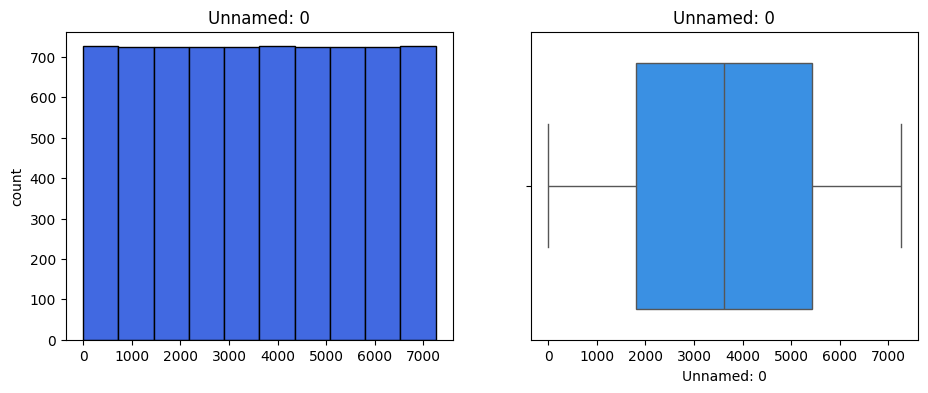


  Vizualisation Year: distribution and visualization of the number of values: 


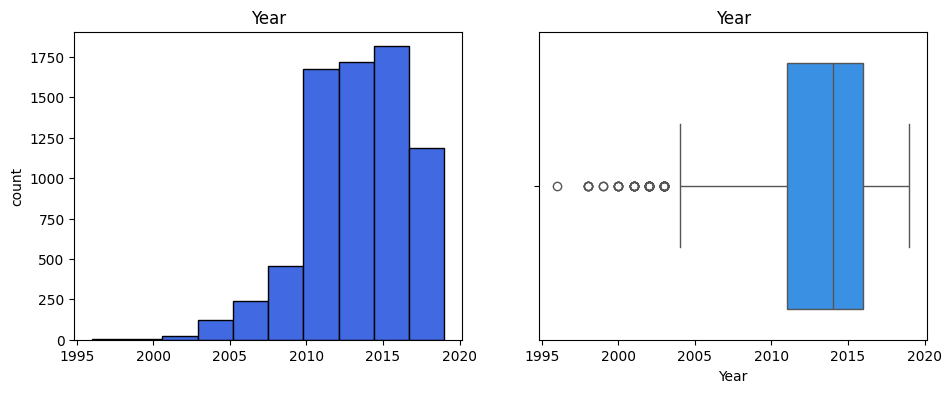


  Vizualisation Kilometers_Driven: distribution and visualization of the number of values: 


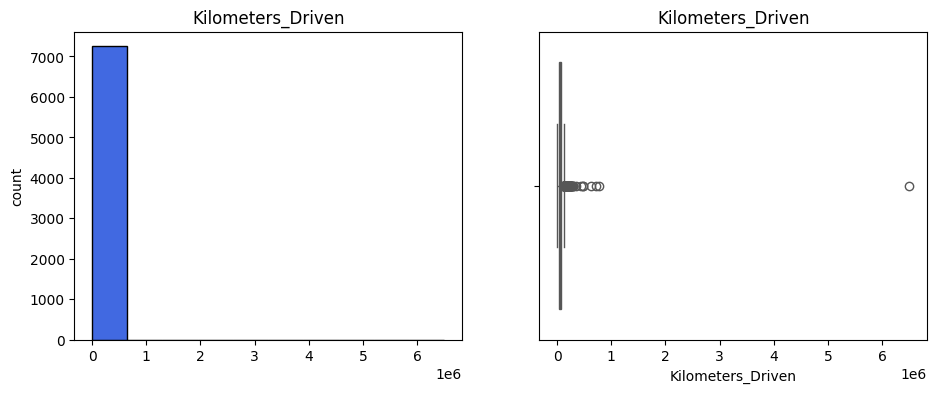


  Vizualisation Engine: distribution and visualization of the number of values: 


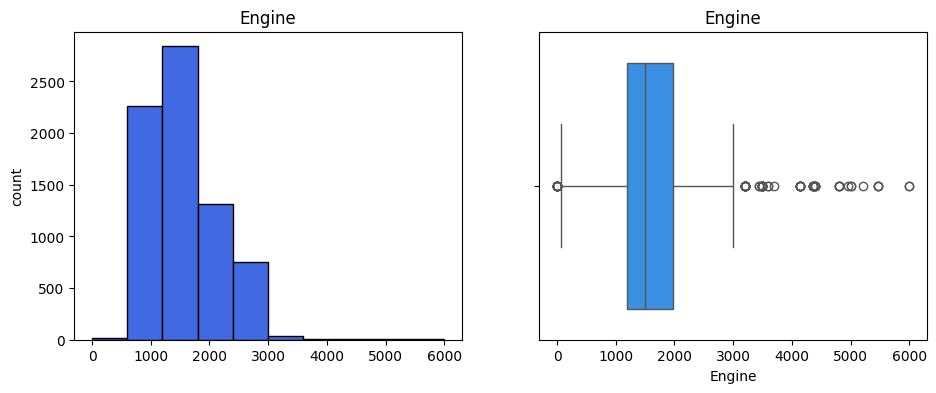


  Vizualisation Seats: distribution and visualization of the number of values: 


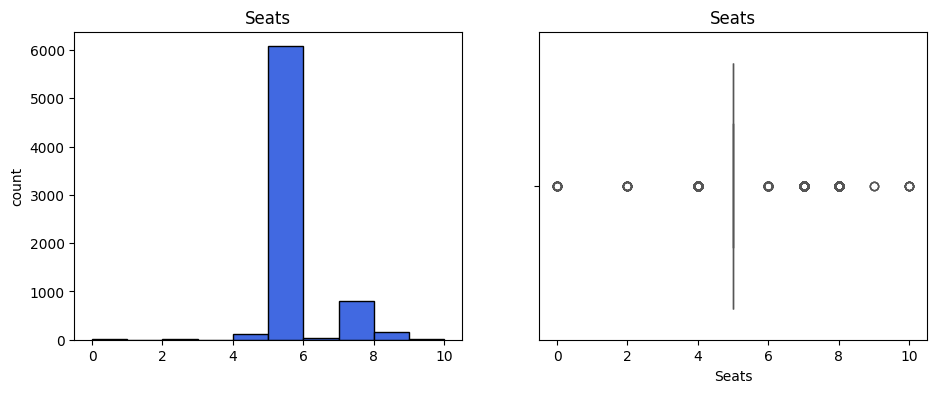


  Vizualisation Price: distribution and visualization of the number of values: 


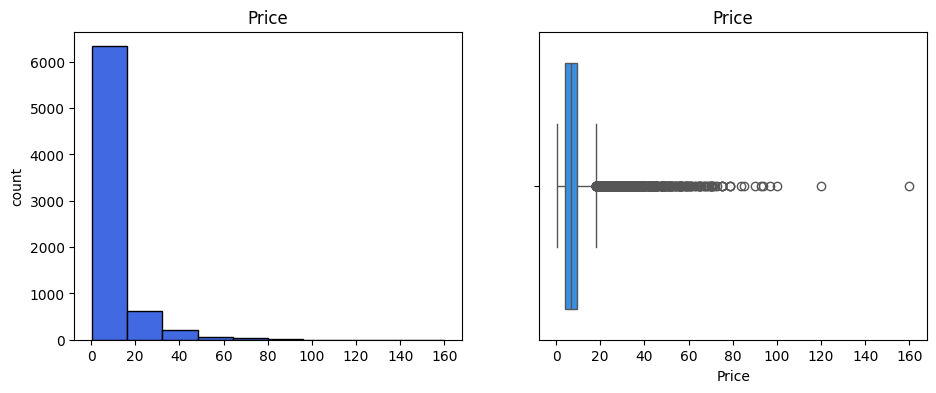


  Vizualisation Car_Age: distribution and visualization of the number of values: 


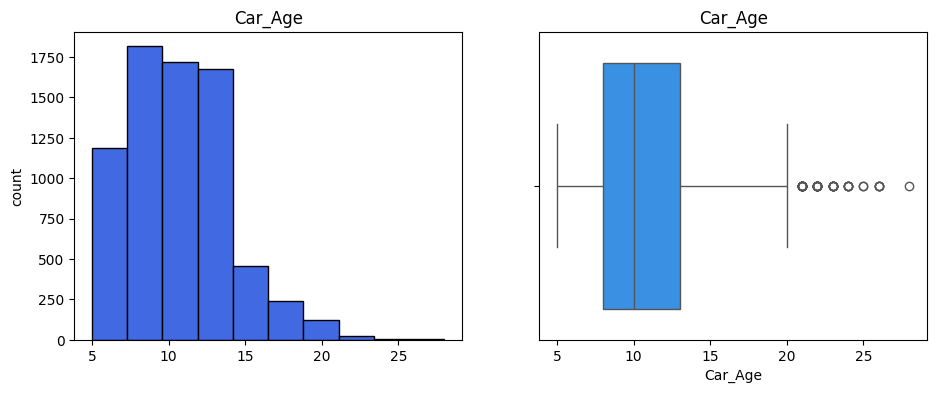


  Vizualisation Mileage: distribution and visualization of the number of values: 


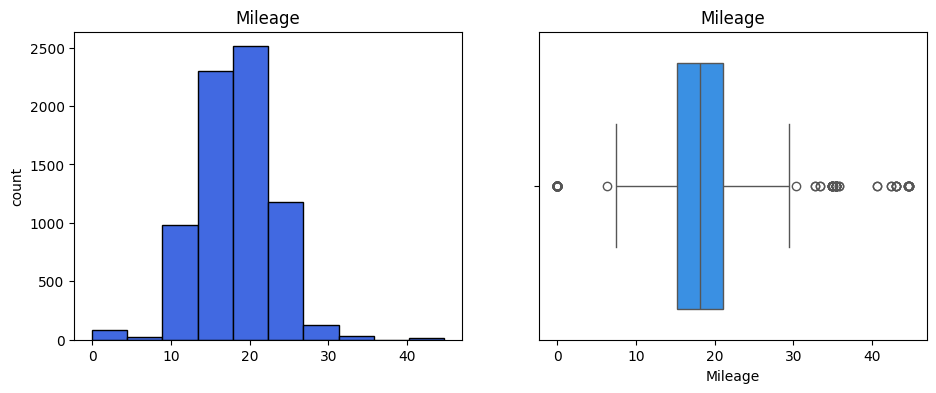


  Vizualisation Power_bhp: distribution and visualization of the number of values: 


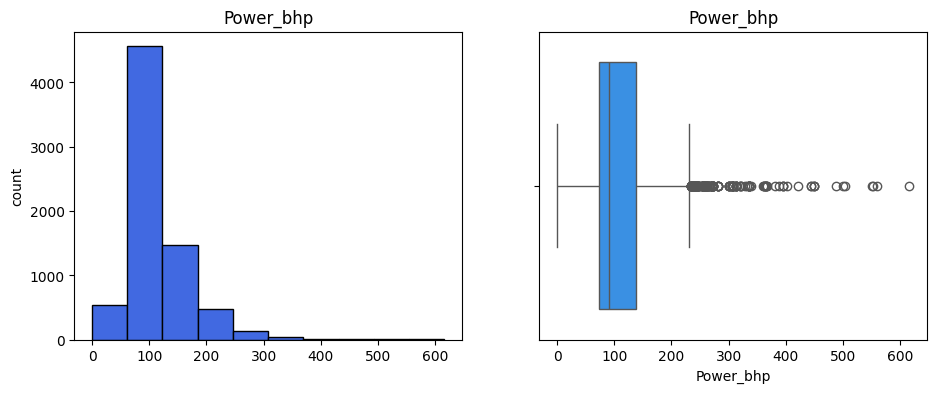


  Vizualisation New_Price_last: distribution and visualization of the number of values: 


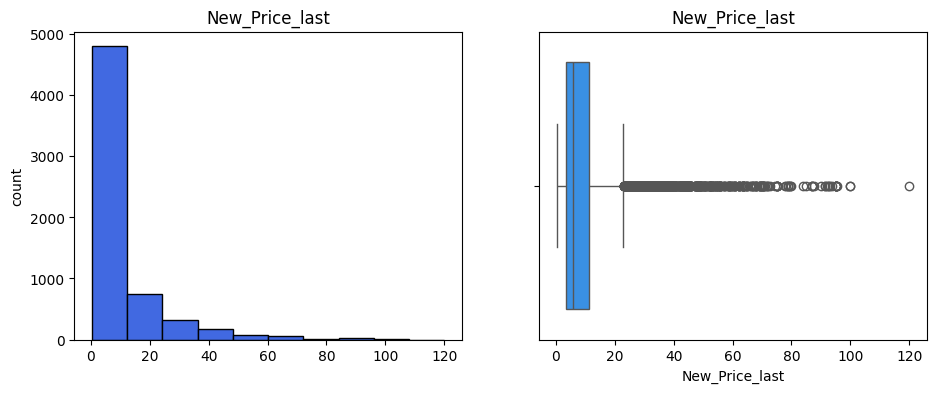


  Vizualisation Kilometers_Driven_log: distribution and visualization of the number of values: 


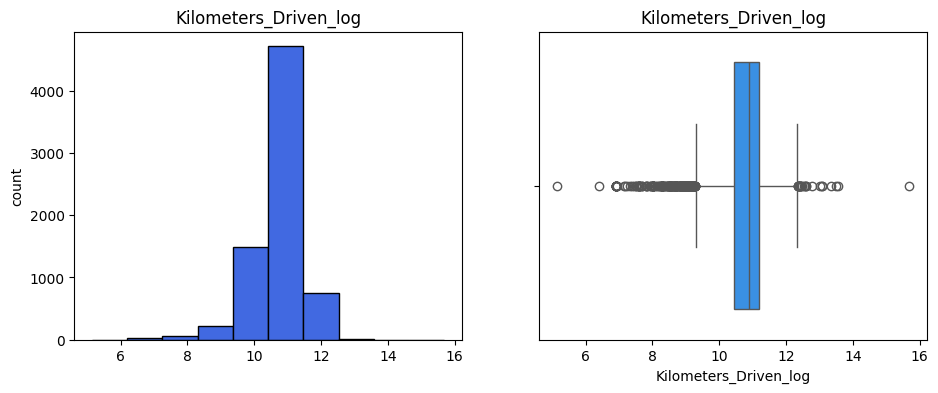


  Vizualisation Price_log: distribution and visualization of the number of values: 


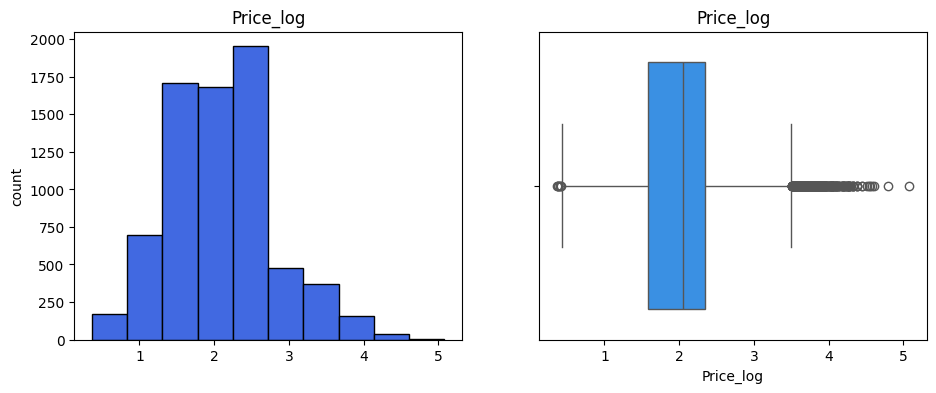

In [ ]:
for col in num_cols:
    print(f'\n  Vizualisation {col}: distribution and visualization of the number of values: ')
    plt.figure(figsize = (11, 4))

    plt.subplot(1, 2, 1)
    data[col].hist(grid=False,
                   color = 'royalblue',
                   edgecolor='black')
    plt.title(col)
    plt.ylabel('count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col],
                color = 'dodgerblue')
    plt.title(col)

    plt.show()

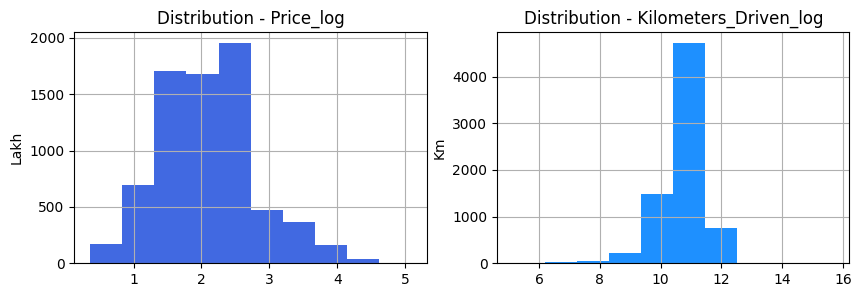

In [ ]:
# логарифмирование столбцов Kilometers_Driven и Price

# Преобразование - применение логарифма к каждому значению "большой" переменной.
for colname in ['Kilometers_Driven','Price']:
    data[colname + '_log'] = np.log1p(data[colname])

# data['Kilometers_Driven_log'].hist(grid=False, color = 'orange')
# data['Price_log'].hist(grid=False, color = 'steelblue')

plt.figure(figsize = (10, 3))

plt.subplot(1, 2, 1)
plt.title('Distribution - Price_log')
plt.ylabel('Lakh')
data['Price_log'].hist(grid=True,
                       color = 'royalblue')

plt.subplot(1, 2, 2)
plt.title('Distribution - Kilometers_Driven_log')
plt.ylabel('Km')
data['Kilometers_Driven_log'].hist(grid=True,
                                   color = 'dodgerblue')

plt.show()

In [ ]:
cat_cols=data.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Variables: {cat_cols} можно визуализировать с помощью столбчатых и круговых диаграмм" )


Categorical Variables: ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Model'] можно визуализировать с помощью столбчатых и круговых диаграмм


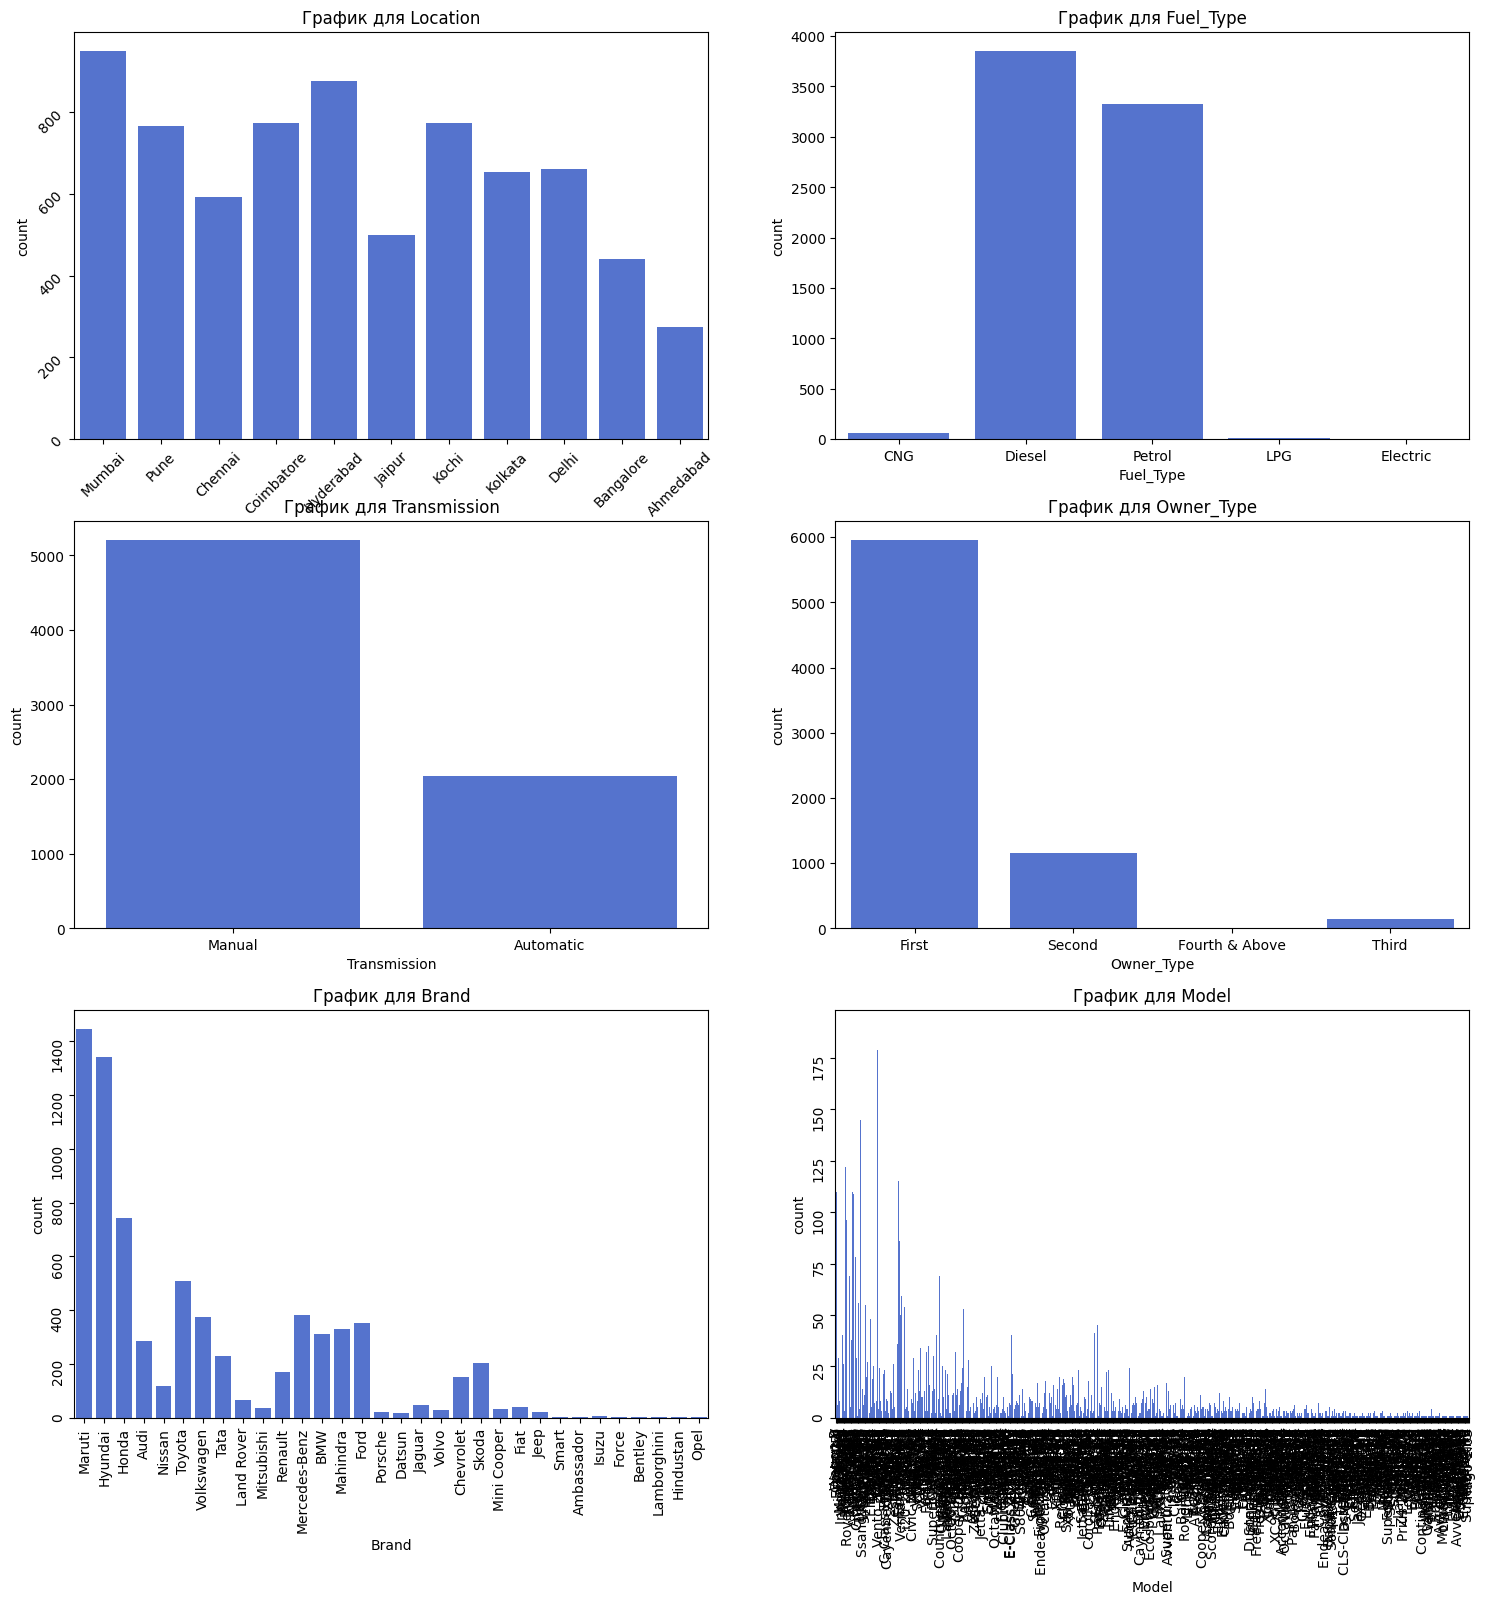

In [ ]:
fig, axes = plt.subplots(3, 2, figsize = (18, 18))

cat_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Model']
for i in range(0,len(cat_cols)):
    #print(cat_cols[i])
    ax = axes[i // 2, i % 2]

    sns.countplot(ax = ax,
                  x = cat_cols[i],
                  data = data,
                  dodge = True,
                  color = 'royalblue')

    ax.set_title(f'График для {cat_cols[i]}')

axes[0][0].tick_params(labelrotation=45)
axes[2][0].tick_params(labelrotation=90)
axes[2][1].tick_params(labelrotation=90)
plt.show()

In [ ]:
''' 3 Выведите информацию о самых крайних выбросах всех столбцов. Проанализируйте,
есть ли среди них ошибки ввода. Ликвидируйте их любым способом,
учитывающим специфику данных. '''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#link = 'https://drive.google.com/file/d/1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-/view'
#link = 'https://drive.google.com/uc?id=1BUeHZbDGVQHPQCSCLafQcQCTyhqQq-h-'
#data = pd.read_csv(link)
#data.head(2)

data = pd.read_csv(file) # берем преобразованный файл
data.head(3)

,Unnamed: 0,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Engine,Seats,Price,Brand,Model,Car_Age,Mileage,Power_bhp,New_Price_last,Kilometers_Driven_log,Price_log
0,0,Mumbai,2010,72000,CNG,Manual,First,998,5,1.75,Maruti,Wagon R,14,35.4578,58.16,1.75,11.184435,1.011601
1,1,Pune,2015,41000,Diesel,Manual,First,1582,5,12.50,Hyundai,Creta 1.6,9,19.6700,126.20,12.50,10.621352,2.602690
2,2,Chennai,2011,46000,Petrol,Manual,First,1199,5,4.50,Honda,Jazz V,13,18.2000,88.70,8.61,10.736418,1.704748


In [ ]:
# крайние выбросы - это числовые столбцы
# num_cols = data.select_dtypes(include=np.number).columns.tolist()
# print(f"Numerical Variables: {num_cols}  можно визуализировать с помощью гистограмм, ​​диаграмм “ящик с усами”, диаграмм плотности и др.")

num_cols = data.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical Variables: {num_cols}  можно визуализировать с помощью гистограмм, ​​диаграмм “ящик с усами”, диаграмм плотности и др.")


Numerical Variables: ['Unnamed: 0', 'Year', 'Kilometers_Driven', 'Engine', 'Seats', 'Price', 'Car_Age', 'Mileage', 'Power_bhp', 'New_Price_last', 'Kilometers_Driven_log', 'Price_log']  можно визуализировать с помощью гистограмм, ​​диаграмм “ящик с усами”, диаграмм плотности и др.


In [ ]:
data[num_cols].describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,7253.0,3626.000000,2093.905084,0.000000,1813.000000,3626.000000,5439.000000,7.252000e+03
Year,7253.0,2013.365366,3.254421,1996.000000,2011.000000,2014.000000,2016.000000,2.019000e+03
Kilometers_Driven,7253.0,58699.063146,84427.720583,171.000000,34000.000000,53416.000000,73000.000000,6.500000e+06
Engine,7253.0,1612.239625,599.425967,0.000000,1197.000000,1493.000000,1968.000000,5.998000e+03
Seats,7253.0,5.263064,0.859879,0.000000,5.000000,5.000000,5.000000,1.000000e+01
Price,7253.0,9.479468,10.191695,0.440000,3.850000,6.750000,9.479468,1.600000e+02
Car_Age,7253.0,10.634634,3.254421,5.000000,8.000000,10.000000,13.000000,2.800000e+01
Mileage,7253.0,18.224336,4.778888,0.000000,15.260000,18.200000,21.100000,4.470882e+01
Power_bhp,7235.0,110.756274,55.216601,0.000000,74.000000,91.720000,138.030000,6.160000e+02
New_Price_last,6201.0,10.615325,13.032884,0.440000,3.600000,5.990000,11.370000,1.200000e+02


In [ ]:
# Ошибки ввода я на этих данных уже исправила в 1м задании. Далее идет вывод нижних и верхних выбросов.


  Vizualisation Year: distribution and description of values 

xmin=1996 <--lower_bound1=2004.75-[Q1=2011.0-center=2014.0-Q3=2016.0]-upper_bound1=2022.25--> xmax=2019 
Выбросы ниже нижней границы по   Year  :  [1996 1998 1999 2000 2001 2002 2003 2004]
Выбросы выше верхней границы по  Year  :  []


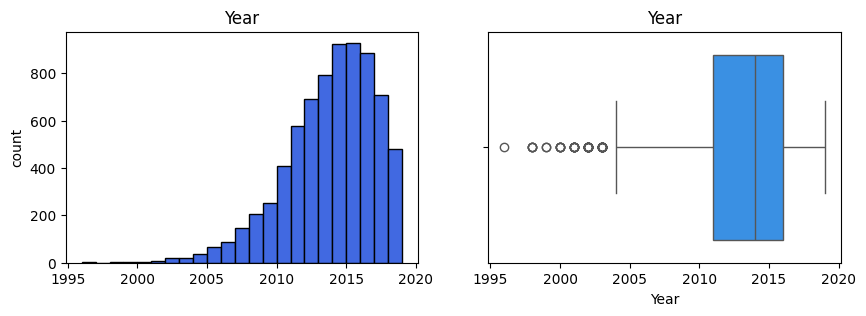


  Vizualisation Kilometers_Driven: distribution and description of values 

xmin=171 <--lower_bound1=-14750.0-[Q1=34000.0-center=53416.0-Q3=73000.0]-upper_bound1=121750.0--> xmax=6500000 
Выбросы ниже нижней границы по   Kilometers_Driven  :  []
Выбросы выше верхней границы по  Kilometers_Driven  :  [ 121812  121900  122000  122086  122397  122800  123000  123200  123600
  123880  123900  124000  124298  124313  124652  125000  125600  125928
  125943  126000  127000  127001  127079  127510  127887  128000  128813
  129000  129750  129986  130000  130002  130790  130923  131000  131503
  131765  132000  133000  133944  134000  134487  135000  135670  136000
  136441  136490  136642  136997  137000  137008  137148  137711  137800
  138000  138205  139000  140000  141537  141844  142000  142299  143000
  143017  143143  143275  143354  144000  144113  144400  144471  145000
  145277  145278  146000  146300  146824  147000  147202  147350  147848
  147898  148000  148009  149000  149706 

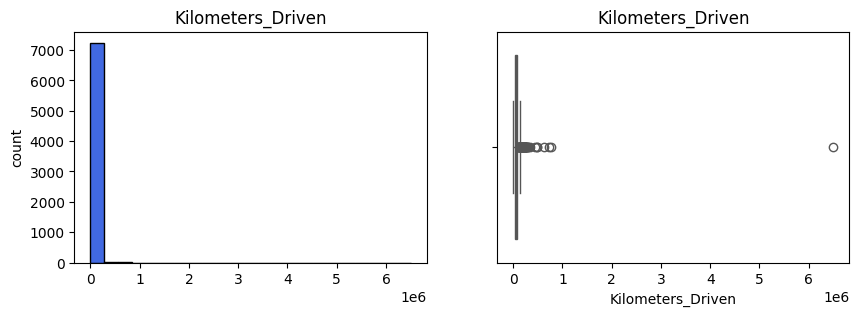


  Vizualisation Engine: distribution and description of values 

xmin=0 <--lower_bound1=233.25-[Q1=1197.0-center=1493.0-Q3=1968.0]-upper_bound1=2931.75--> xmax=5998 
Выбросы ниже нижней границы по   Engine  :  [ 0 72]
Выбросы выше верхней границы по  Engine  :  [2953 2956 2967 2979 2982 2987 2993 2995 2996 2997 2999 3197 3198 3200
 3436 3498 3597 3696 4134 4367 4395 4806 4951 5000 5204 5461 5998]


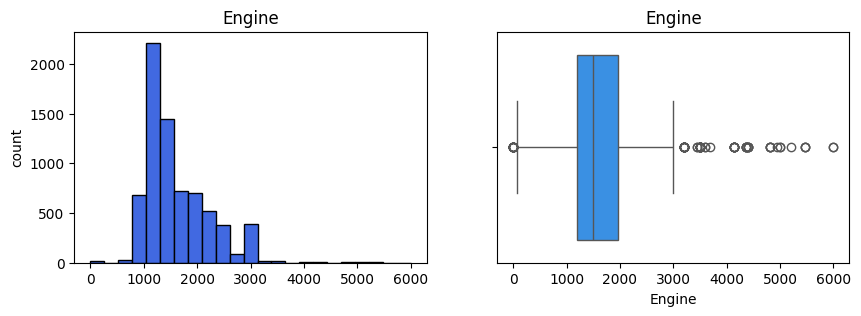


  Vizualisation Seats: distribution and description of values 

xmin=0 <--lower_bound1=5.0-[Q1=5.0-center=5.0-Q3=5.0]-upper_bound1=5.0--> xmax=10 
Выбросы ниже нижней границы по   Seats  :  [0 2 4]
Выбросы выше верхней границы по  Seats  :  [ 6  7  8  9 10]


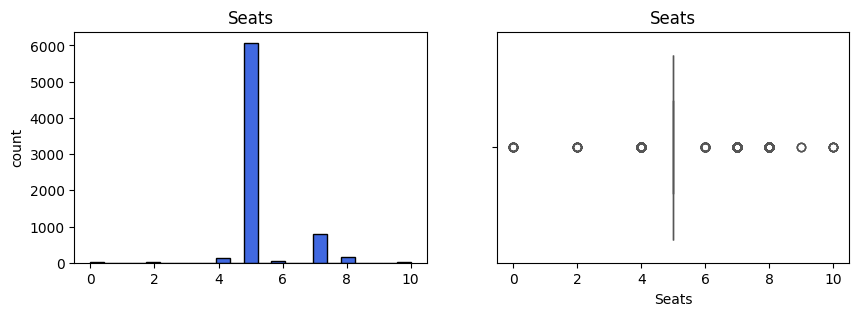


  Vizualisation Price: distribution and description of values 

xmin=0.44 <--lower_bound1=-3.186835437780362-[Q1=3.85-center=6.75-Q3=9.47946835022429]-upper_bound1=16.516303788004652--> xmax=160.0 
Выбросы ниже нижней границы по   Price  :  []
Выбросы выше верхней границы по  Price  :  [ 16.52  16.56  16.57  16.58  16.59  16.61  16.67  16.68  16.75  16.77
  16.8   16.81  16.85  16.9   16.95  17.    17.02  17.08  17.09  17.11
  17.15  17.18  17.22  17.23  17.25  17.27  17.45  17.49  17.5   17.51
  17.55  17.56  17.63  17.65  17.71  17.74  17.75  17.85  17.89  17.9
  17.92  17.95  17.98  17.99  18.    18.06  18.12  18.25  18.36  18.39
  18.46  18.49  18.5   18.55  18.58  18.6   18.64  18.65  18.75  18.9
  18.95  18.98  19.    19.03  19.05  19.25  19.4   19.41  19.46  19.48
  19.5   19.6   19.64  19.65  19.75  19.8   19.85  19.86  19.9   19.92
  19.94  19.97  19.99  20.    20.04  20.11  20.12  20.14  20.25  20.26
  20.28  20.37  20.4   20.5   20.57  20.67  20.72  20.75  20.77  20.87
  20

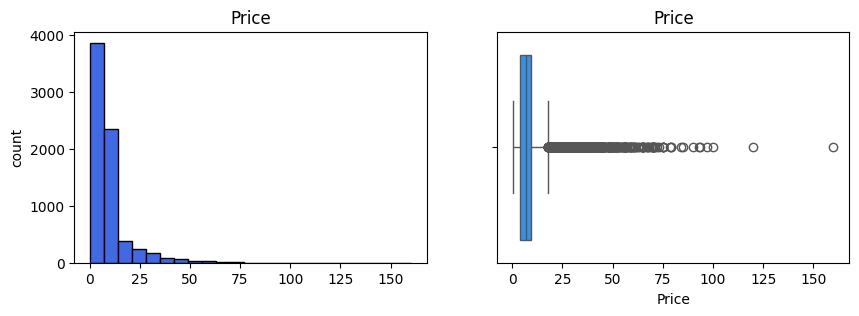


  Vizualisation Car_Age: distribution and description of values 

xmin=5 <--lower_bound1=1.75-[Q1=8.0-center=10.0-Q3=13.0]-upper_bound1=19.25--> xmax=28 
Выбросы ниже нижней границы по   Car_Age  :  []
Выбросы выше верхней границы по  Car_Age  :  [20 21 22 23 24 25 26 28]


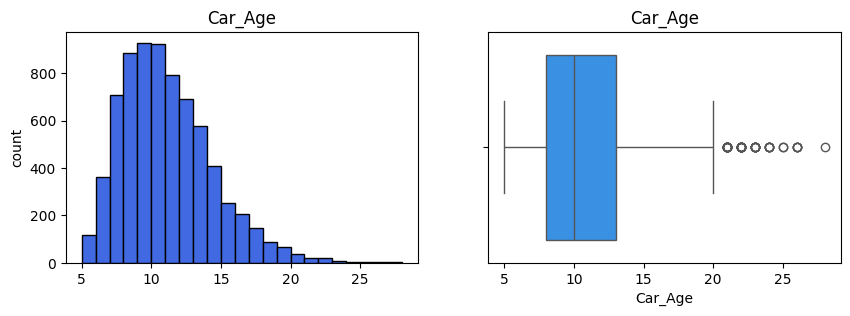


  Vizualisation Mileage: distribution and description of values 

xmin=0.0 <--lower_bound1=7.959999999999997-[Q1=15.26-center=18.2-Q3=21.1]-upper_bound1=28.400000000000006--> xmax=44.70882 
Выбросы ниже нижней границы по   Mileage  :  [0.   6.4  7.5  7.81 7.94]
Выбросы выше верхней границы по  Mileage  :  [28.5262  29.4593  30.3924  32.7918  33.325   34.9246  35.0579  35.4578
 35.76439 40.60318 42.37607 43.00258 44.57552 44.70882]


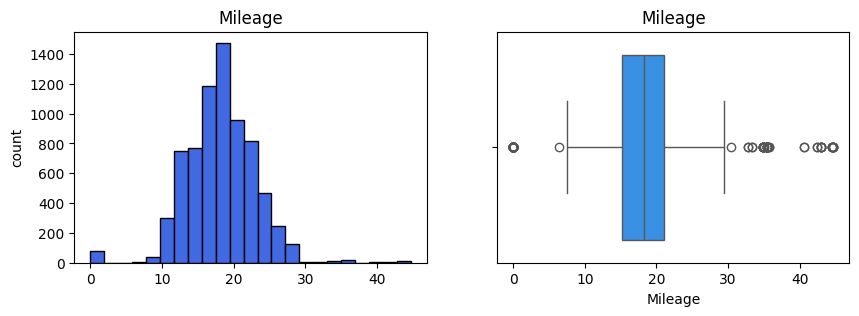


  Vizualisation Power_bhp: distribution and description of values 

xmin=0.0 <--lower_bound1=-6.037499999999994-[Q1=74.0-center=91.72-Q3=138.03]-upper_bound1=218.0675--> xmax=616.0 
Выбросы ниже нижней границы по   Power_bhp  :  []
Выбросы выше верхней границы по  Power_bhp  :  [224.   224.34 226.6  227.   231.1  235.   236.   237.4  240.   241.
 241.38 241.4  241.6  245.   245.41 246.7  246.74 250.   252.   254.
 254.79 254.8  255.   258.   261.   261.49 261.5  262.6  265.   270.88
 270.9  271.23 271.72 272.   281.61 282.   300.   301.73 306.   308.
 308.43 313.   320.   321.   328.5  333.   335.2  335.3  340.   360.
 362.07 362.9  364.9  367.   382.   387.3  394.3  395.   402.   421.
 444.   450.   488.1  500.   503.   550.   552.   560.   616.  ]


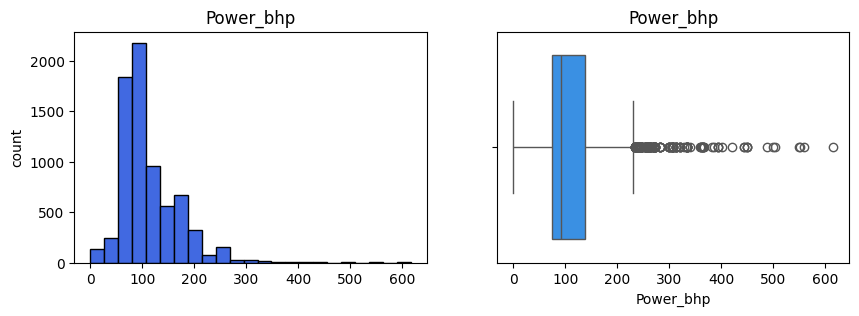


  Vizualisation New_Price_last: distribution and description of values 

xmin=0.44 <--lower_bound1=-6.112499999999999-[Q1=3.6-center=5.99-Q3=11.37]-upper_bound1=21.082499999999996--> xmax=120.0 
Выбросы ниже нижней границы по   New_Price_last  :  []
Выбросы выше верхней границы по  New_Price_last  :  [ 21.1   21.33  21.36  21.37  21.38  21.43  21.5   21.56  21.6   21.67
  21.69  21.72  21.75  21.77  21.8   21.9   21.94  21.95  21.99  22.
  22.25  22.37  22.43  22.46  22.5   22.58  22.66  22.74  22.75  22.86
  22.87  22.95  22.99  23.    23.06  23.14  23.19  23.25  23.29  23.32
  23.37  23.41  23.45  23.5   23.58  23.64  23.65  23.68  23.75  23.86
  23.89  23.94  23.99  24.    24.01  24.02  24.22  24.25  24.26  24.36
  24.5   24.51  24.63  24.74  24.75  24.82  24.85  24.94  24.95  24.99
  25.    25.02  25.04  25.12  25.27  25.31  25.4   25.46  25.49  25.5
  25.51  25.52  25.54  25.64  25.7   25.71  25.72  25.75  25.81  25.82
  25.93  26.    26.14  26.45  26.5   26.52  26.55  26.56  26.

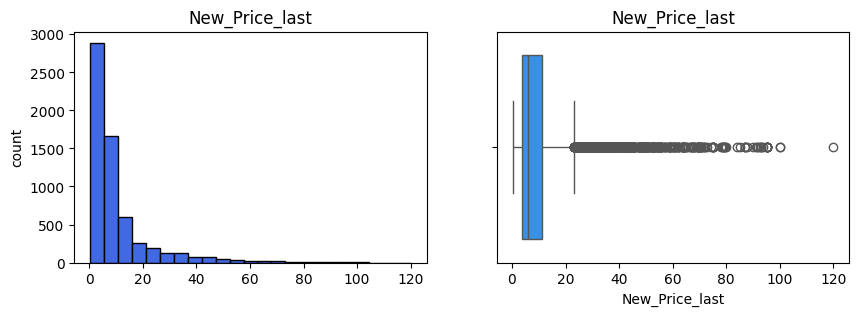


  Vizualisation Kilometers_Driven_log: distribution and description of values 

xmin=5.147494476813453 <--lower_bound1=9.479041210260045-[Q1=10.434145214930487-center=10.885884326344947-Q3=11.19822841866684]-upper_bound1=12.153332423337282--> xmax=15.687312888712007 
Выбросы ниже нижней границы по   Kilometers_Driven_log  :  [5.14749448 6.39859493 6.90875478 6.90975328 6.91968385 6.92362863
 6.95559261 7.14045304 7.19443685 7.24494155 7.32712329 7.3889461
 7.43897159 7.49609735 7.55013534 7.59990196 7.60140233 7.6501687
 7.69484807 7.69666708 7.82444593 7.83478811 7.83636976 7.93773178
 7.96935774 7.97281078 7.99699041 8.00670085 8.01102338 8.04012466
 8.10198073 8.1356399  8.18896686 8.21039626 8.24301947 8.26898821
 8.2705251  8.27486682 8.28374675 8.29429961 8.29878839 8.32530603
 8.32651683 8.33158624 8.33997857 8.36915711 8.41205487 8.45553053
 8.45723085 8.45998772 8.47657951 8.49719454 8.51739317 8.52615293
 8.5642676  8.58578598 8.59007184 8.5943394  8.60465447 8.61268517
 8.6

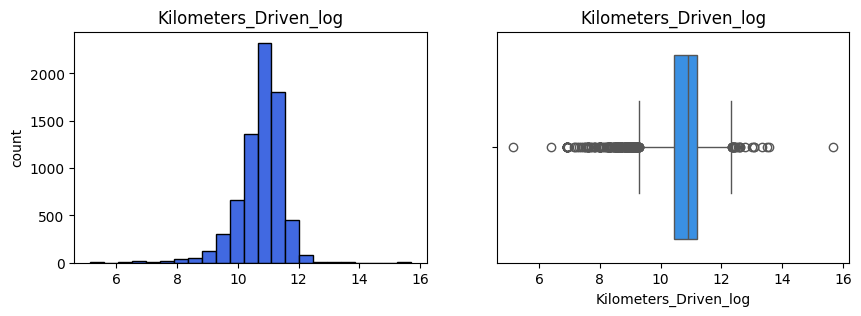


  Vizualisation Price_log: distribution and description of values 

xmin=0.36464311358790924 <--lower_bound1=0.6159296515540585-[Q1=1.578978704949392-center=2.0476928433652555-Q3=2.3494179476656587]-upper_bound1=3.312467001060992--> xmax=5.081404364984463 
Выбросы ниже нижней границы по   Price_log  :  [0.36464311 0.37156356 0.40546511 0.41210965 0.42526774 0.43825493
 0.47000363 0.48858001 0.50077529 0.52472853 0.53062825 0.55961579
 0.57097955 0.58778666 0.5988365  0.61518564]
Выбросы выше верхней границы по  Price_log  :  [3.314186   3.31491301 3.32143241 3.32323584 3.32359614 3.32431634
 3.33220451 3.33612538 3.33754735 3.3428618  3.34462703 3.3449797
 3.34744493 3.34990409 3.35863777 3.36280299 3.3655702  3.36729583
 3.36832978 3.37587957 3.38167472 3.38269391 3.38439026 3.38608374
 3.38878736 3.39282913 3.39417277 3.39618484 3.39718936 3.39785848
 3.39952932 3.40119738 3.40784192 3.41114771 3.41444261 3.41772668
 3.41838221 3.42100001 3.42230634 3.42328498 3.42654019 3.42751469


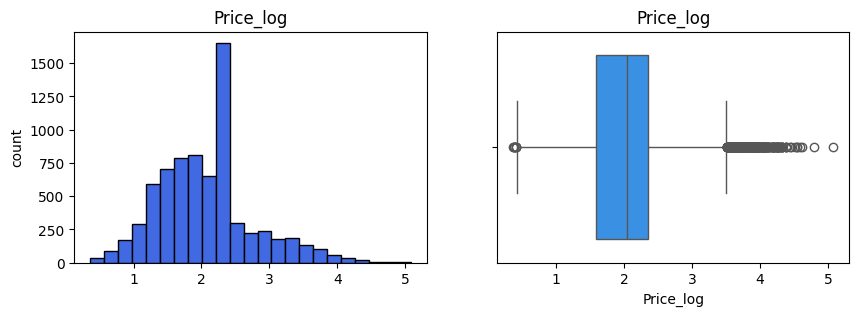

In [ ]:
for col in ['Year', 'Kilometers_Driven', 'Engine', 'Seats', 'Price', 'Car_Age', 'Mileage', 'Power_bhp', 'New_Price_last', 'Kilometers_Driven_log', 'Price_log']:
    print(f'\n  Vizualisation {col}: distribution and description of values ')

    # 1 data processing
    xmin =  data[col].min()
    #Q0 = data[col].quantile(0)
    Q1 = data[col].quantile(0.25)
    Q2 = data[col].quantile(0.5)
    center = Q2
    xmean =  data[col].mean()
    xmode =  data[col].mode()
    Q3 = data[col].quantile(0.75)
    xmax =  data[col].max()

    IQR = Q3 - Q1
    lower_bound = Q1 - IQR
    upper_bound = Q3 + IQR
    lower_bound1 = Q1 - IQR*1.25
    upper_bound1 = Q3 + IQR*1.25
    # {lower_bound=} {upper_bound=}
    # print(f'{xmin=} <-- - [{Q1=} -- {center=} -- {Q3=}] - --> {xmax=} ')
    # print(f' {lower_bound=} -- {xmean=} {center=} {xmode=} -- {upper_bound=} ')
    # print(f' {lower_bound1=} --  -- {upper_bound1=} ')
    # print(f'{delta_min=} {Q2-Q1=} | {Q3-Q2=} {delta_max=} {IQR=}')
    delta_min = abs(Q1 - xmin)
    delta_max = abs(xmax - Q3)

    print(f'\n{xmin=} <--{lower_bound1=}-[{Q1=}-{center=}-{Q3=}]-{upper_bound1=}--> {xmax=} ')

    dfmin = data[data[col] < lower_bound1 ][col].sort_values()
    dfmax = data[data[col]>upper_bound1][col].sort_values()

    print('Выбросы ниже нижней границы по  ', col, ' : ', dfmin.unique())
    print('Выбросы выше верхней границы по ', col, ' : ', dfmax.unique())
    # 2 graphs
    plt.figure(figsize = (10,3))

    plt.subplot(1, 2, 1)
    data[col].hist(grid=False,
                   bins = 23,
                   color = 'royalblue',
                   edgecolor='black')
    plt.title(col)
    plt.ylabel('count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[col],
                color = 'dodgerblue')
    plt.title(col)

    plt.show()